ENVIRONMENT
Ultralytics version: 8.4.155
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4

LOCATING DATASET
Dataset found: /kaggle/input/datasets/abirbot69/dangerous-23

CREATING WRITABLE DATASET COPY
Original read-only dataset:
/kaggle/input/datasets/abirbot69/dangerous-23

Writable dataset:
/kaggle/working/dangerous_23_cleaned_3oznn06d

Folder check:
Train images           FOUND  /kaggle/working/dangerous_23_cleaned_3oznn06d/train/images
Train labels           FOUND  /kaggle/working/dangerous_23_cleaned_3oznn06d/train/labels
Validation images      FOUND  /kaggle/working/dangerous_23_cleaned_3oznn06d/valid/images
Validation labels      FOUND  /kaggle/working/dangerous_23_cleaned_3oznn06d/valid/labels
Test images            FOUND  /kaggle/working/dangerous_23_cleaned_3oznn06d/test/images
Test labels            FOUND  /kaggle/working/dangerous_23_cleaned_3oznn06d/test/labels

VALIDATING AND REPAIRING ANNOTATIONS
Checking: train
Checking: validation
Checking: test

Annota

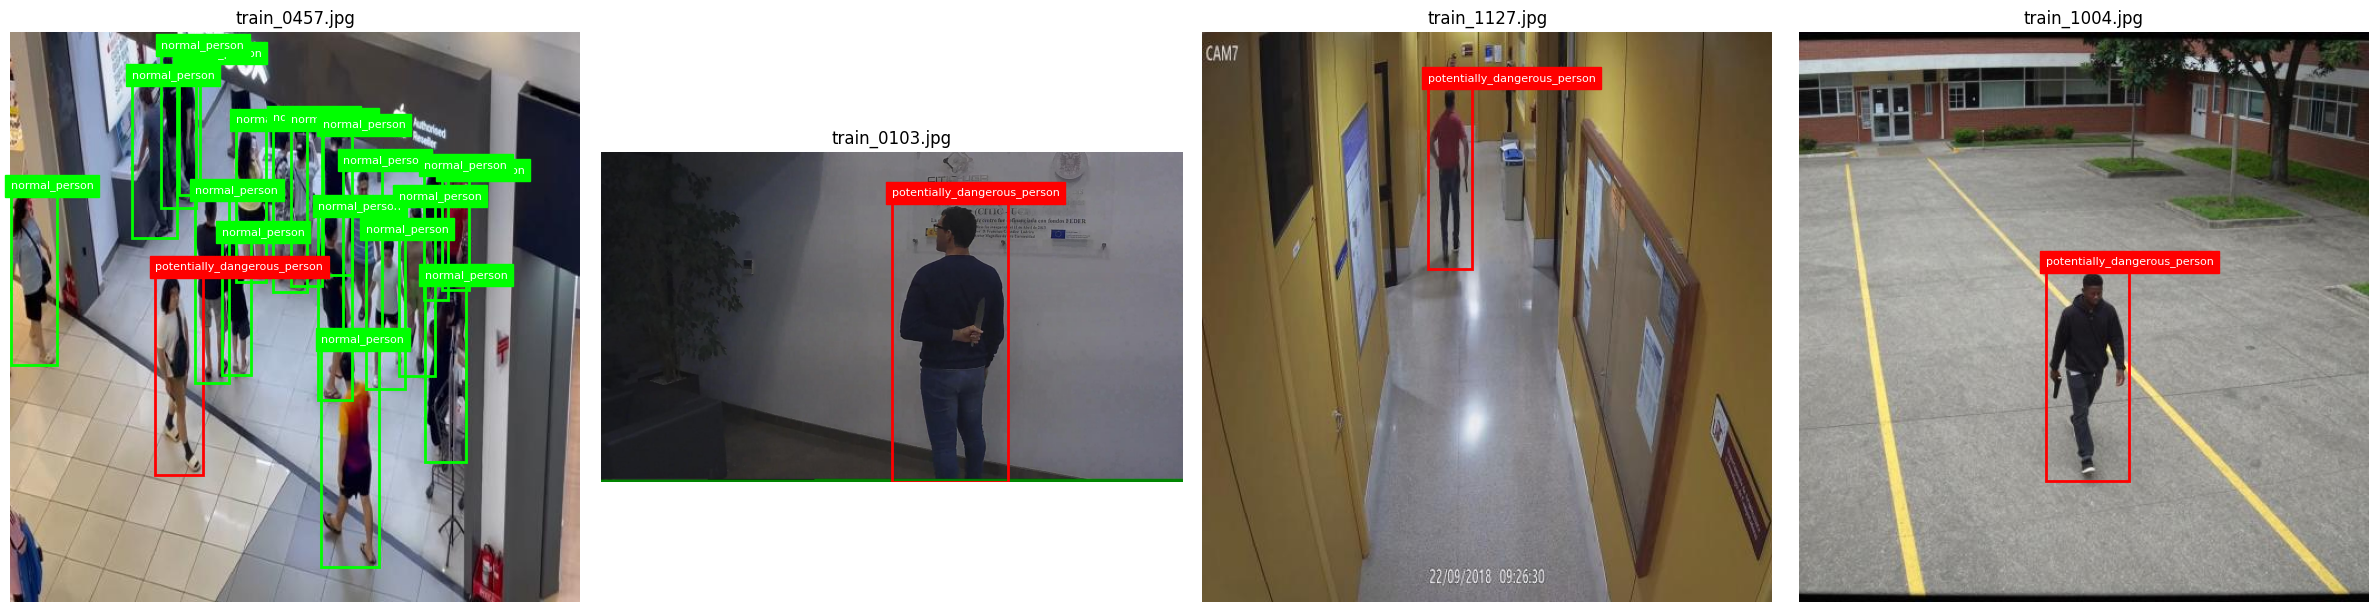


TRAINING yolo11s.pt
Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_yolo11_run_h9n63lvj

,Model,Evaluation split,Precision,Recall,F1-score,mAP50,mAP50-95
0,yolo11s.pt,test,0.798228,0.730464,0.762844,0.82031,0.642691



RUNNING PREDICTIONS
Results saved to /kaggle/working/predictions/yolo11s_yolo11_run_h9n63lvj
311 labels saved to /kaggle/working/predictions/yolo11s_yolo11_run_h9n63lvj/labels
Saved prediction images: 314


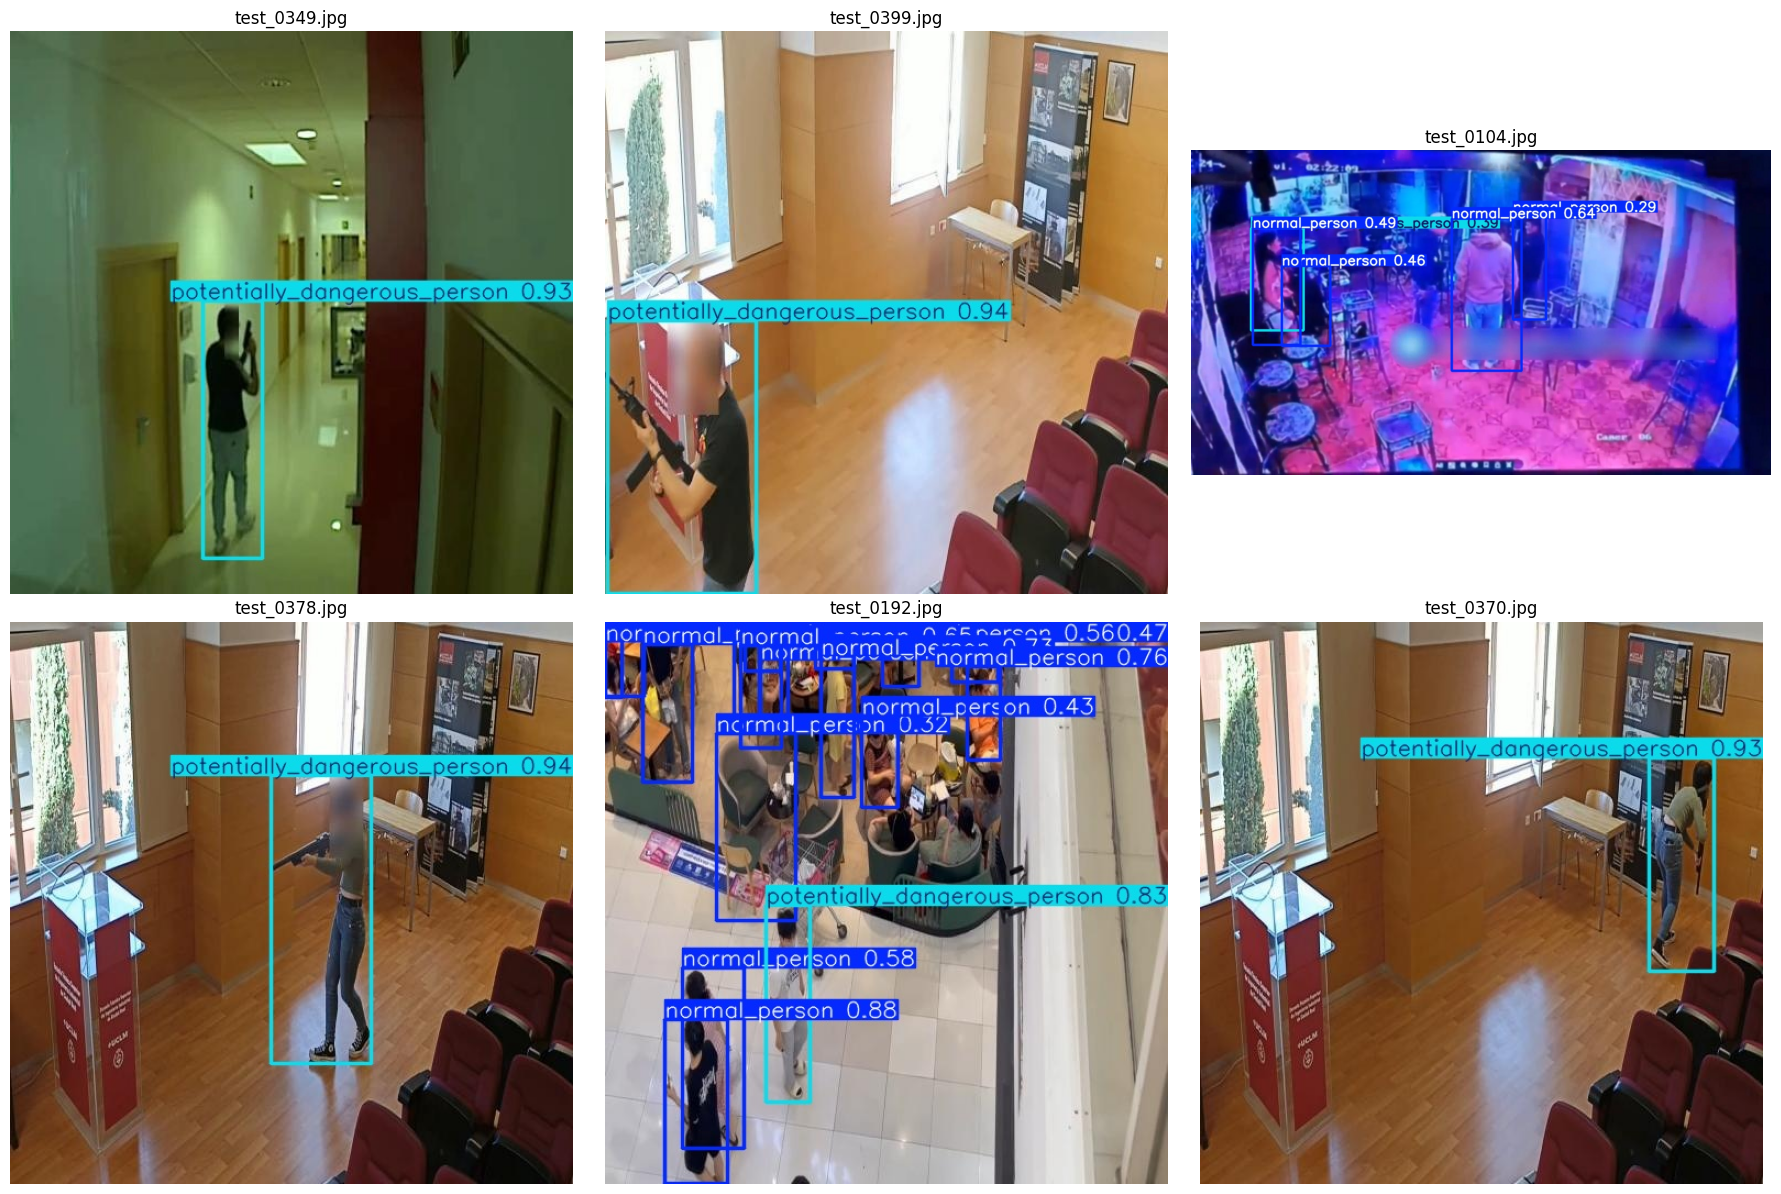


EXPORTING RESULTS

PIPELINE COMPLETED SUCCESSFULLY

Best trained model:
/kaggle/working/best_dangerous_person_yolo11s.pt

Generated data.yaml:
/kaggle/working/data.yaml

Final metrics:
/kaggle/working/final_metrics.csv

Annotation repair report:
/kaggle/working/annotation_repair_log.json

Downloadable ZIP:
/kaggle/working/dangerous_person_project_results.zip

Download the model and ZIP from the Kaggle Output/Files panel.


In [6]:
# ================================================================
# DANGEROUS-PERSON DETECTION WITH YOLO11
# COMPLETE KAGGLE PIPELINE — SINGLE CELL
# ================================================================

# Kaggle:
# Settings → Accelerator → GPU
# Settings → Internet → On

# --------------------------- SETTINGS ---------------------------

CLASS_NAMES = [
    "normal_person",                 # Class 0
    "potentially_dangerous_person"   # Class 1
]

MODEL_NAME = "yolo11s.pt"

EPOCHS = 100
IMAGE_SIZE = 640
BATCH_SIZE = 16
PATIENCE = 20
SEED = 42

CONFIDENCE_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
RUN_PREDICTIONS = True

# Your exact Kaggle dataset path from the previous error:
PREFERRED_DATASET_PATH = (
    "/kaggle/input/datasets/abirbot69/dangerous-23"
)

# ================================================================
# 1. INSTALL PACKAGES
# ================================================================

import sys
import subprocess

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "ultralytics",
        "pyyaml"
    ],
    check=True
)

# ================================================================
# 2. IMPORT PACKAGES
# ================================================================

import os
import json
import yaml
import shutil
import random
import hashlib
import tempfile
import warnings

from pathlib import Path
from collections import Counter

import torch
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO
import ultralytics

warnings.filterwarnings("ignore")
random.seed(SEED)

print("=" * 72)
print("ENVIRONMENT")
print("=" * 72)
print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    DEVICE = 0
    print("GPU:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    print("\nWARNING: GPU is not enabled.")
    print("Enable it from Kaggle Settings → Accelerator → GPU")

# ================================================================
# 3. LOCATE DATASET
# ================================================================

print("\n" + "=" * 72)
print("LOCATING DATASET")
print("=" * 72)

preferred_path = Path(PREFERRED_DATASET_PATH)

def is_valid_dataset_root(folder):
    folder = Path(folder)

    has_train = (
        (folder / "train/images").is_dir()
        and (folder / "train/labels").is_dir()
    )

    has_validation = (
        (
            (folder / "valid/images").is_dir()
            and (folder / "valid/labels").is_dir()
        )
        or
        (
            (folder / "val/images").is_dir()
            and (folder / "val/labels").is_dir()
        )
    )

    return has_train and has_validation

if is_valid_dataset_root(preferred_path):
    SOURCE_DATASET_ROOT = preferred_path
else:
    print("Preferred path was not found.")
    print("Searching inside /kaggle/input...")

    candidate_roots = []

    for train_images_folder in Path(
        "/kaggle/input"
    ).rglob("train/images"):

        candidate_root = train_images_folder.parent.parent

        if is_valid_dataset_root(candidate_root):
            candidate_roots.append(candidate_root)

    candidate_roots = list(
        dict.fromkeys(candidate_roots)
    )

    if not candidate_roots:
        print("\nFolders available inside /kaggle/input:")

        for path in Path("/kaggle/input").rglob("*"):
            if path.is_dir():
                print(path)

        raise FileNotFoundError(
            "Could not find a dataset containing train/images, "
            "train/labels, valid/images and valid/labels."
        )

    SOURCE_DATASET_ROOT = candidate_roots[0]

print("Dataset found:", SOURCE_DATASET_ROOT)

# ================================================================
# 4. COPY DATASET TO WRITABLE STORAGE
# ================================================================

print("\n" + "=" * 72)
print("CREATING WRITABLE DATASET COPY")
print("=" * 72)

# Never modify or delete /kaggle/input.
working_directory = tempfile.mkdtemp(
    prefix="dangerous_23_cleaned_",
    dir="/kaggle/working"
)

DATASET_ROOT = Path(working_directory)

shutil.copytree(
    src=str(SOURCE_DATASET_ROOT),
    dst=str(DATASET_ROOT),
    dirs_exist_ok=True,
    symlinks=False
)

print("Original read-only dataset:")
print(SOURCE_DATASET_ROOT)

print("\nWritable dataset:")
print(DATASET_ROOT)

# Detect validation folder name.
if (
    (DATASET_ROOT / "valid/images").is_dir()
    and (DATASET_ROOT / "valid/labels").is_dir()
):
    VAL_FOLDER_NAME = "valid"

elif (
    (DATASET_ROOT / "val/images").is_dir()
    and (DATASET_ROOT / "val/labels").is_dir()
):
    VAL_FOLDER_NAME = "val"

else:
    raise FileNotFoundError(
        "Neither valid/images nor val/images was found."
    )

TRAIN_IMAGES = DATASET_ROOT / "train/images"
TRAIN_LABELS = DATASET_ROOT / "train/labels"

VAL_IMAGES = DATASET_ROOT / VAL_FOLDER_NAME / "images"
VAL_LABELS = DATASET_ROOT / VAL_FOLDER_NAME / "labels"

TEST_IMAGES = DATASET_ROOT / "test/images"
TEST_LABELS = DATASET_ROOT / "test/labels"

HAS_TEST_SET = (
    TEST_IMAGES.is_dir()
    and TEST_LABELS.is_dir()
)

folders_to_check = {
    "Train images": TRAIN_IMAGES,
    "Train labels": TRAIN_LABELS,
    "Validation images": VAL_IMAGES,
    "Validation labels": VAL_LABELS,
    "Test images": TEST_IMAGES,
    "Test labels": TEST_LABELS
}

print("\nFolder check:")

for folder_name, folder_path in folders_to_check.items():
    status = "FOUND" if folder_path.exists() else "MISSING"

    print(
        f"{folder_name:<22} {status}  {folder_path}"
    )

required_folders = [
    TRAIN_IMAGES,
    TRAIN_LABELS,
    VAL_IMAGES,
    VAL_LABELS
]

missing_required_folders = [
    str(folder)
    for folder in required_folders
    if not folder.exists()
]

if missing_required_folders:
    raise FileNotFoundError(
        "Required dataset folders are missing:\n"
        + "\n".join(missing_required_folders)
    )

# ================================================================
# 5. HELPER FUNCTIONS
# ================================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
}

def get_images(folder):
    folder = Path(folder)

    if not folder.exists():
        return []

    return sorted([
        file
        for file in folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ])

def get_labels(folder):
    folder = Path(folder)

    if not folder.exists():
        return []

    return sorted(folder.rglob("*.txt"))

def corresponding_label(
    image_path,
    image_root,
    label_root
):
    relative_path = image_path.relative_to(image_root)

    return (
        Path(label_root)
        / relative_path.with_suffix(".txt")
    )

# ================================================================
# 6. CLEAN AND REPAIR ANNOTATIONS
# ================================================================

print("\n" + "=" * 72)
print("VALIDATING AND REPAIRING ANNOTATIONS")
print("=" * 72)

repair_log = []

total_valid_annotations = 0
total_repaired_annotations = 0
total_removed_annotations = 0

def clean_label_file(label_path):
    global total_valid_annotations
    global total_repaired_annotations
    global total_removed_annotations

    original_lines = label_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()

    cleaned_lines = []

    for line_number, original_line in enumerate(
        original_lines,
        start=1
    ):
        line = original_line.strip()

        if not line:
            continue

        values = line.split()

        if len(values) != 5:
            total_removed_annotations += 1

            repair_log.append({
                "file": str(label_path),
                "line": line_number,
                "original": original_line,
                "action": "removed",
                "reason": (
                    f"Expected 5 values; found {len(values)}"
                )
            })

            continue

        try:
            class_value = float(values[0])
            class_id = int(class_value)

            x_center = float(values[1])
            y_center = float(values[2])
            box_width = float(values[3])
            box_height = float(values[4])

        except ValueError:
            total_removed_annotations += 1

            repair_log.append({
                "file": str(label_path),
                "line": line_number,
                "original": original_line,
                "action": "removed",
                "reason": "Invalid numeric value"
            })

            continue

        if class_value != class_id:
            total_removed_annotations += 1

            repair_log.append({
                "file": str(label_path),
                "line": line_number,
                "original": original_line,
                "action": "removed",
                "reason": "Class ID is not a whole integer"
            })

            continue

        if class_id < 0 or class_id >= len(CLASS_NAMES):
            total_removed_annotations += 1

            repair_log.append({
                "file": str(label_path),
                "line": line_number,
                "original": original_line,
                "action": "removed",
                "reason": f"Invalid class ID: {class_id}"
            })

            continue

        if box_width <= 0 or box_height <= 0:
            total_removed_annotations += 1

            repair_log.append({
                "file": str(label_path),
                "line": line_number,
                "original": original_line,
                "action": "removed",
                "reason": "Width or height is zero/negative"
            })

            continue

        # Convert YOLO center format into corner format.
        original_x1 = x_center - box_width / 2
        original_y1 = y_center - box_height / 2
        original_x2 = x_center + box_width / 2
        original_y2 = y_center + box_height / 2

        # Clip the box to valid normalized image boundaries.
        x1 = max(0.0, min(1.0, original_x1))
        y1 = max(0.0, min(1.0, original_y1))
        x2 = max(0.0, min(1.0, original_x2))
        y2 = max(0.0, min(1.0, original_y2))

        if x2 <= x1 or y2 <= y1:
            total_removed_annotations += 1

            repair_log.append({
                "file": str(label_path),
                "line": line_number,
                "original": original_line,
                "action": "removed",
                "reason": "Bounding box has no visible area"
            })

            continue

        # Convert clipped corners back into YOLO format.
        new_x_center = (x1 + x2) / 2
        new_y_center = (y1 + y2) / 2
        new_width = x2 - x1
        new_height = y2 - y1

        cleaned_line = (
            f"{class_id} "
            f"{new_x_center:.6f} "
            f"{new_y_center:.6f} "
            f"{new_width:.6f} "
            f"{new_height:.6f}"
        )

        box_was_changed = any([
            abs(original_x1 - x1) > 1e-8,
            abs(original_y1 - y1) > 1e-8,
            abs(original_x2 - x2) > 1e-8,
            abs(original_y2 - y2) > 1e-8
        ])

        if box_was_changed:
            total_repaired_annotations += 1

            repair_log.append({
                "file": str(label_path),
                "line": line_number,
                "original": original_line,
                "replacement": cleaned_line,
                "action": "repaired",
                "reason": (
                    "Bounding box extended outside image boundary"
                )
            })
        else:
            total_valid_annotations += 1

        cleaned_lines.append(cleaned_line)

    output_text = "\n".join(cleaned_lines)

    if output_text:
        output_text += "\n"

    label_path.write_text(
        output_text,
        encoding="utf-8"
    )

split_label_folders = [
    ("train", TRAIN_LABELS),
    ("validation", VAL_LABELS)
]

if HAS_TEST_SET:
    split_label_folders.append(
        ("test", TEST_LABELS)
    )

for split_name, label_folder in split_label_folders:
    print("Checking:", split_name)

    for label_file in get_labels(label_folder):
        clean_label_file(label_file)

print("\nAnnotation results:")
print("Valid annotation lines:", total_valid_annotations)
print("Repaired annotation lines:", total_repaired_annotations)
print("Removed annotation lines:", total_removed_annotations)

if repair_log:
    print("\nAnnotation changes:")

    for change in repair_log[:20]:
        print("\nFile:", change["file"])
        print("Line:", change["line"])
        print("Action:", change["action"])
        print("Reason:", change["reason"])
        print("Original:", repr(change["original"]))

        if "replacement" in change:
            print("Replacement:", change["replacement"])

ANNOTATION_LOG_PATH = Path(
    "/kaggle/working/annotation_repair_log.json"
)

with open(
    ANNOTATION_LOG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        repair_log,
        file,
        indent=2
    )

# ================================================================
# 7. VERIFY DATASET AFTER REPAIR
# ================================================================

print("\n" + "=" * 72)
print("DATASET SUMMARY")
print("=" * 72)

dataset_statistics = []

def inspect_split(
    split_name,
    image_folder,
    label_folder
):
    images = get_images(image_folder)
    labels = get_labels(label_folder)

    class_counts = Counter()
    missing_labels = []
    empty_labels = []

    for image_path in images:
        label_path = corresponding_label(
            image_path,
            image_folder,
            label_folder
        )

        if not label_path.exists():
            missing_labels.append(str(image_path))
            continue

        content = label_path.read_text(
            encoding="utf-8",
            errors="ignore"
        ).strip()

        if not content:
            empty_labels.append(str(label_path))
            continue

        for line in content.splitlines():
            values = line.split()

            if len(values) == 5:
                class_id = int(float(values[0]))
                class_counts[class_id] += 1

    summary = {
        "split": split_name,
        "images": len(images),
        "labels": len(labels),
        "missing_labels": len(missing_labels),
        "empty_labels": len(empty_labels),
        "class_counts": {
            CLASS_NAMES[class_id]: class_counts[class_id]
            for class_id in range(len(CLASS_NAMES))
        }
    }

    print(f"\n{split_name.upper()}")
    print("Images:", len(images))
    print("Label files:", len(labels))
    print("Images without label files:", len(missing_labels))
    print("Empty/background labels:", len(empty_labels))

    for class_id, class_name in enumerate(CLASS_NAMES):
        print(
            f"Class {class_id} ({class_name}):",
            class_counts[class_id],
            "instances"
        )

    if missing_labels:
        print("\nExamples without label files:")

        for path in missing_labels[:5]:
            print(" -", path)

    return summary

dataset_statistics.append(
    inspect_split(
        "train",
        TRAIN_IMAGES,
        TRAIN_LABELS
    )
)

dataset_statistics.append(
    inspect_split(
        "validation",
        VAL_IMAGES,
        VAL_LABELS
    )
)

if HAS_TEST_SET:
    dataset_statistics.append(
        inspect_split(
            "test",
            TEST_IMAGES,
            TEST_LABELS
        )
    )

if len(get_images(TRAIN_IMAGES)) == 0:
    raise ValueError("The training image folder is empty.")

if len(get_images(VAL_IMAGES)) == 0:
    raise ValueError("The validation image folder is empty.")

# ================================================================
# 8. CHECK EXACT DUPLICATES ACROSS SPLITS
# ================================================================

print("\n" + "=" * 72)
print("CHECKING EXACT IMAGE DUPLICATES")
print("=" * 72)

def calculate_file_hash(file_path):
    hasher = hashlib.sha256()

    with open(file_path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            hasher.update(chunk)

    return hasher.hexdigest()

def collect_hashes(image_folder):
    hashes = {}

    for image_path in get_images(image_folder):
        image_hash = calculate_file_hash(image_path)

        hashes.setdefault(
            image_hash,
            []
        ).append(str(image_path))

    return hashes

train_hashes = collect_hashes(TRAIN_IMAGES)
validation_hashes = collect_hashes(VAL_IMAGES)

train_validation_overlap = (
    set(train_hashes)
    & set(validation_hashes)
)

duplicate_report = {
    "train_validation": len(
        train_validation_overlap
    )
}

print(
    "Train–validation duplicates:",
    len(train_validation_overlap)
)

if HAS_TEST_SET:
    test_hashes = collect_hashes(TEST_IMAGES)

    train_test_overlap = (
        set(train_hashes)
        & set(test_hashes)
    )

    validation_test_overlap = (
        set(validation_hashes)
        & set(test_hashes)
    )

    duplicate_report["train_test"] = len(
        train_test_overlap
    )

    duplicate_report["validation_test"] = len(
        validation_test_overlap
    )

    print(
        "Train–test duplicates:",
        len(train_test_overlap)
    )

    print(
        "Validation–test duplicates:",
        len(validation_test_overlap)
    )

if sum(duplicate_report.values()) > 0:
    print(
        "\nWARNING: Exact duplicate images exist across splits."
    )
    print(
        "Remove them before reporting final research results."
    )

# ================================================================
# 9. CREATE DATA.YAML
# ================================================================

print("\n" + "=" * 72)
print("CREATING DATA.YAML")
print("=" * 72)

YAML_PATH = Path("/kaggle/working/data.yaml")

data_configuration = {
    "train": str(TRAIN_IMAGES),
    "val": str(VAL_IMAGES),
    "names": CLASS_NAMES,
    "nc": len(CLASS_NAMES)
}

if HAS_TEST_SET:
    data_configuration["test"] = str(TEST_IMAGES)

with open(
    YAML_PATH,
    "w",
    encoding="utf-8"
) as file:
    yaml.safe_dump(
        data_configuration,
        file,
        sort_keys=False,
        allow_unicode=True
    )

print(YAML_PATH.read_text())

# Save dataset report.
DATASET_REPORT_PATH = Path(
    "/kaggle/working/dataset_report.json"
)

dataset_report = {
    "source_dataset": str(SOURCE_DATASET_ROOT),
    "writable_dataset": str(DATASET_ROOT),
    "classes": CLASS_NAMES,
    "statistics": dataset_statistics,
    "annotation_cleaning": {
        "valid_annotations": total_valid_annotations,
        "repaired_annotations": total_repaired_annotations,
        "removed_annotations": total_removed_annotations
    },
    "duplicate_check": duplicate_report
}

with open(
    DATASET_REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        dataset_report,
        file,
        indent=2
    )

# ================================================================
# 10. DISPLAY SAMPLE ANNOTATIONS
# ================================================================

print("\n" + "=" * 72)
print("DISPLAYING SAMPLE ANNOTATIONS")
print("=" * 72)

def show_samples(
    image_folder,
    label_folder,
    number_of_samples=4
):
    images = get_images(image_folder)

    if not images:
        return

    selected_images = random.sample(
        images,
        min(number_of_samples, len(images))
    )

    figure, axes = plt.subplots(
        1,
        len(selected_images),
        figsize=(6 * len(selected_images), 6)
    )

    if len(selected_images) == 1:
        axes = [axes]

    class_colors = [
        "lime",
        "red"
    ]

    for axis, image_path in zip(
        axes,
        selected_images
    ):
        image = Image.open(
            image_path
        ).convert("RGB")

        image_width, image_height = image.size

        axis.imshow(image)
        axis.set_title(image_path.name)
        axis.axis("off")

        label_path = corresponding_label(
            image_path,
            image_folder,
            label_folder
        )

        if not label_path.exists():
            continue

        content = label_path.read_text().strip()

        if not content:
            continue

        for line in content.splitlines():
            class_id, xc, yc, width, height = map(
                float,
                line.split()
            )

            class_id = int(class_id)

            x1 = (xc - width / 2) * image_width
            y1 = (yc - height / 2) * image_height

            pixel_width = width * image_width
            pixel_height = height * image_height

            color = class_colors[
                class_id % len(class_colors)
            ]

            rectangle = plt.Rectangle(
                (x1, y1),
                pixel_width,
                pixel_height,
                fill=False,
                edgecolor=color,
                linewidth=2
            )

            axis.add_patch(rectangle)

            axis.text(
                x1,
                max(y1 - 5, 5),
                CLASS_NAMES[class_id],
                color="white",
                fontsize=8,
                backgroundcolor=color
            )

    plt.tight_layout()
    plt.show()

show_samples(
    TRAIN_IMAGES,
    TRAIN_LABELS,
    number_of_samples=4
)

# ================================================================
# 11. TRAIN YOLO11S
# ================================================================

print("\n" + "=" * 72)
print("TRAINING", MODEL_NAME)
print("=" * 72)

RUN_IDENTIFIER = Path(
    tempfile.mkdtemp(
        prefix="yolo11_run_",
        dir="/kaggle/working"
    )
).name

PROJECT_DIRECTORY = Path(
    "/kaggle/working/dangerous_person_runs"
)

EXPERIMENT_NAME = (
    f"{Path(MODEL_NAME).stem}_{RUN_IDENTIFIER}"
)

model = YOLO(MODEL_NAME)

model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=4,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    seed=SEED,
    deterministic=True,
    pretrained=True,
    amp=True,
    cache=False,
    plots=True,
    verbose=True,
    project=str(PROJECT_DIRECTORY),
    name=EXPERIMENT_NAME,
    exist_ok=False
)

TRAINING_DIRECTORY = (
    PROJECT_DIRECTORY
    / EXPERIMENT_NAME
)

BEST_MODEL_PATH = (
    TRAINING_DIRECTORY
    / "weights"
    / "best.pt"
)

LAST_MODEL_PATH = (
    TRAINING_DIRECTORY
    / "weights"
    / "last.pt"
)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"best.pt was not found: {BEST_MODEL_PATH}"
    )

print("\nTraining completed.")
print("Best model:", BEST_MODEL_PATH)
print("Last model:", LAST_MODEL_PATH)

# ================================================================
# 12. FINAL TEST EVALUATION
# ================================================================

print("\n" + "=" * 72)
print("FINAL EVALUATION")
print("=" * 72)

best_model = YOLO(str(BEST_MODEL_PATH))

evaluation_split = (
    "test"
    if HAS_TEST_SET
    else "val"
)

EVALUATION_PROJECT = Path(
    "/kaggle/working/final_evaluation"
)

evaluation_metrics = best_model.val(
    data=str(YAML_PATH),
    split=evaluation_split,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    plots=True,
    project=str(EVALUATION_PROJECT),
    name=EXPERIMENT_NAME,
    exist_ok=False
)

precision = float(evaluation_metrics.box.mp)
recall = float(evaluation_metrics.box.mr)
map50 = float(evaluation_metrics.box.map50)
map50_95 = float(evaluation_metrics.box.map)

f1_score = (
    2 * precision * recall
    / (precision + recall + 1e-12)
)

print("\nFINAL RESULTS")
print("Evaluation split:", evaluation_split)
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1_score, 4))
print("mAP50:", round(map50, 4))
print("mAP50–95:", round(map50_95, 4))

metrics_dataframe = pd.DataFrame([
    {
        "Model": MODEL_NAME,
        "Evaluation split": evaluation_split,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1_score,
        "mAP50": map50,
        "mAP50-95": map50_95
    }
])

FINAL_METRICS_PATH = Path(
    "/kaggle/working/final_metrics.csv"
)

metrics_dataframe.to_csv(
    FINAL_METRICS_PATH,
    index=False
)

display(metrics_dataframe)

# ================================================================
# 13. RUN PREDICTIONS
# ================================================================

PREDICTION_PROJECT = Path(
    "/kaggle/working/predictions"
)

PREDICTION_NAME = EXPERIMENT_NAME

if RUN_PREDICTIONS:
    print("\n" + "=" * 72)
    print("RUNNING PREDICTIONS")
    print("=" * 72)

    prediction_source = (
        TEST_IMAGES
        if HAS_TEST_SET
        else VAL_IMAGES
    )

    best_model.predict(
        source=str(prediction_source),
        conf=CONFIDENCE_THRESHOLD,
        iou=IOU_THRESHOLD,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        save=True,
        save_txt=True,
        save_conf=True,
        project=str(PREDICTION_PROJECT),
        name=PREDICTION_NAME,
        exist_ok=False,
        verbose=False
    )

    prediction_directory = (
        PREDICTION_PROJECT
        / PREDICTION_NAME
    )

    prediction_images = get_images(
        prediction_directory
    )

    print(
        "Saved prediction images:",
        len(prediction_images)
    )

    if prediction_images:
        selected_predictions = random.sample(
            prediction_images,
            min(6, len(prediction_images))
        )

        figure, axes = plt.subplots(
            2,
            3,
            figsize=(18, 12)
        )

        axes = axes.flatten()

        for axis in axes:
            axis.axis("off")

        for index, image_path in enumerate(
            selected_predictions
        ):
            prediction_image = Image.open(
                image_path
            ).convert("RGB")

            axes[index].imshow(prediction_image)
            axes[index].set_title(image_path.name)

        plt.tight_layout()
        plt.show()

# ================================================================
# 14. EXPORT MODEL AND RESULTS
# ================================================================

print("\n" + "=" * 72)
print("EXPORTING RESULTS")
print("=" * 72)

FINAL_MODEL_PATH = Path(
    "/kaggle/working/"
    "best_dangerous_person_yolo11s.pt"
)

shutil.copy2(
    BEST_MODEL_PATH,
    FINAL_MODEL_PATH
)

EXPORT_DIRECTORY = Path(
    tempfile.mkdtemp(
        prefix="dangerous_person_export_",
        dir="/kaggle/working"
    )
)

essential_files = [
    FINAL_MODEL_PATH,
    YAML_PATH,
    FINAL_METRICS_PATH,
    DATASET_REPORT_PATH,
    ANNOTATION_LOG_PATH
]

for source_file in essential_files:
    if source_file.exists():
        shutil.copy2(
            source_file,
            EXPORT_DIRECTORY / source_file.name
        )

training_files = [
    "results.csv",
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
    "labels.jpg",
    "labels_correlogram.jpg"
]

for filename in training_files:
    source_file = TRAINING_DIRECTORY / filename

    if source_file.exists():
        shutil.copy2(
            source_file,
            EXPORT_DIRECTORY / filename
        )

evaluation_directory = (
    EVALUATION_PROJECT
    / EXPERIMENT_NAME
)

if evaluation_directory.exists():
    shutil.copytree(
        evaluation_directory,
        EXPORT_DIRECTORY / "final_evaluation",
        dirs_exist_ok=True
    )

RESULTS_ZIP_PATH = shutil.make_archive(
    "/kaggle/working/"
    "dangerous_person_project_results",
    "zip",
    root_dir=str(EXPORT_DIRECTORY)
)

print("\n" + "=" * 72)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 72)

print("\nBest trained model:")
print(FINAL_MODEL_PATH)

print("\nGenerated data.yaml:")
print(YAML_PATH)

print("\nFinal metrics:")
print(FINAL_METRICS_PATH)

print("\nAnnotation repair report:")
print(ANNOTATION_LOG_PATH)

print("\nDownloadable ZIP:")
print(RESULTS_ZIP_PATH)

print(
    "\nDownload the model and ZIP from the "
    "Kaggle Output/Files panel."
)